# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/reetuparabat/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [17]:
"""
1) The research question and the decision it supports

Question: among a client's pages, which ones are worth reviewing first for
content refresh -- and does a trained model beat a transparent, hand-written
rule at answering that, on the same held-out data?

The decision this supports: a content strategist has limited weekly review
time. This ranks pages so the highest-value review happens first, with a
plain-language reason attached to every row -- it does not publish, delete,
or redirect anything on its own (see Section 6 / the playbook's no-go list).
"""


"\n1) The research question and the decision it supports\n\nQuestion: among a client's pages, which ones are worth reviewing first for\ncontent refresh -- and does a trained model beat a transparent, hand-written\nrule at answering that, on the same held-out data?\n\nThe decision this supports: a content strategist has limited weekly review\ntime. This ranks pages so the highest-value review happens first, with a\nplain-language reason attached to every row -- it does not publish, delete,\nor redirect anything on its own (see Section 6 / the playbook's no-go list).\n"

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [18]:
!git clone https://github.com/reetuparabat/flyrank-ml-internship.git


fatal: destination path 'flyrank-ml-internship' already exists and is not an empty directory.


In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv')
print(f'Rows: {len(df):,} | Columns: {df.shape[1]} | Clients: {df["client_id"].nunique()}')
print(f'Content types: {df["content_type"].nunique()} | Date-independent snapshot (90-day trailing metrics)')


Rows: 30,000 | Columns: 44 | Clients: 32
Content types: 3 | Date-independent snapshot (90-day trailing metrics)


In [20]:
"""
2) Data -- release, tables, windows, exclusions

Source: the FlyRank ML Internship starter dataset, content_refresh_anonymized.csv
-- a pseudonymized extract standing in for the full 79M-row production warehouse
(fact_content_daily_performance + dim_content), scoped to Lane 2 (Content Refresh
Opportunity Scoring). 30,000 rows, 32 pseudonymous clients, all metrics trailing
90 days as of the snapshot date. No raw dates, URLs, or client names are present
anywhere in this file or in any output this notebook produces.

Excluded, and why (label-derived leakage -- confirmed empirically, not assumed):
trend_direction, trend_pct, and the six last_30d/prev_30d columns they're built
from. r=0.9999999984 between the last30/prev30 computation and the published
trend_pct column -- these columns don't just correlate with the label, they
define it, so they are excluded from every feature set in this notebook.
Also excluded: content_id/client_id (grouping keys only, never features), and
provider_used/model_used (70%+ and 19% missing, not conceptually predictive).
"""


"\n2) Data -- release, tables, windows, exclusions\n\nSource: the FlyRank ML Internship starter dataset, content_refresh_anonymized.csv\n-- a pseudonymized extract standing in for the full 79M-row production warehouse\n(fact_content_daily_performance + dim_content), scoped to Lane 2 (Content Refresh\nOpportunity Scoring). 30,000 rows, 32 pseudonymous clients, all metrics trailing\n90 days as of the snapshot date. No raw dates, URLs, or client names are present\nanywhere in this file or in any output this notebook produces.\n\nExcluded, and why (label-derived leakage -- confirmed empirically, not assumed):\ntrend_direction, trend_pct, and the six last_30d/prev_30d columns they're built\nfrom. r=0.9999999984 between the last30/prev30 computation and the published\ntrend_pct column -- these columns don't just correlate with the label, they\ndefine it, so they are excluded from every feature set in this notebook.\nAlso excluded: content_id/client_id (grouping keys only, never features), an

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [21]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)
TARGET = 'is_declining_label'

LEAKY = ['trend_direction', 'trend_pct',
         'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d',
         'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d']
IDS = ['content_id', 'client_id']
DROP_LOW_VALUE = ['provider_used', 'model_used']

feature_cols = [c for c in df.columns if c not in LEAKY + IDS + DROP_LOW_VALUE + [TARGET]]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
categorical_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
SYSTEMATIC_MISSING = ['word_count', 'char_count', 'search_volume', 'competition', 'cpc', 'main_intent']
print(f'{len(numeric_cols)} numeric + {len(categorical_cols)} categorical features, after excluding {len(LEAKY)} leaky columns')


23 numeric + 9 categorical features, after excluding 8 leaky columns


In [22]:
"""
3) Methodology -- assumptions, baseline, validation design, leakage checks

Label: is_declining_label = 1 if trend_direction == "down" (a 30-day-vs-prior-
30-day impression comparison), else 0. This is a same-window proxy, not a
future-outcome label -- named as a limitation in Section 5.

Baseline (Week 4): a transparent rule -- flag a page if it's visible
(impressions_90d >= 500) AND its CTR sits below the mean CTR for its own
position tier. One score, one reason code (ctr_underperforming_for_position),
no model.

Model (Week 5): Logistic Regression beat Random Forest at every K on this
feature set (see Results) -- the simpler model won on its own merits, not by
default. Missingness in word_count/char_count/search_volume/competition/cpc/
main_intent is systematic (tied to content_type, confirmed in the Week-3 data
contract), so each gets a "_was_missing" indicator flag rather than silent
median imputation.

Validation design: GroupShuffleSplit by client_id (75/25), not a random row
split -- confirmed 0 client overlap between train and test. This matters:
re-running the identical model on a random row split (Week 6's audit) showed
31 of 32 clients leaking across the split boundary, inflating AUC from 0.582
to 0.695 and precision@20 from 0.850 to a perfect 1.000. The grouped number is
the honest one.

Leakage check performed, not just claimed: deliberately added
impressions_last_30d back into the honest, grouped-split feature set. AUC
jumped from 0.582 to 0.723 (+0.141) -- confirming both that the exclusion was
correct and that this test harness actually detects leakage when present.
"""


'\n3) Methodology -- assumptions, baseline, validation design, leakage checks\n\nLabel: is_declining_label = 1 if trend_direction == "down" (a 30-day-vs-prior-\n30-day impression comparison), else 0. This is a same-window proxy, not a\nfuture-outcome label -- named as a limitation in Section 5.\n\nBaseline (Week 4): a transparent rule -- flag a page if it\'s visible\n(impressions_90d >= 500) AND its CTR sits below the mean CTR for its own\nposition tier. One score, one reason code (ctr_underperforming_for_position),\nno model.\n\nModel (Week 5): Logistic Regression beat Random Forest at every K on this\nfeature set (see Results) -- the simpler model won on its own merits, not by\ndefault. Missingness in word_count/char_count/search_volume/competition/cpc/\nmain_intent is systematic (tied to content_type, confirmed in the Week-3 data\ncontract), so each gets a "_was_missing" indicator flag rather than silent\nmedian imputation.\n\nValidation design: GroupShuffleSplit by client_id (75/25

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [23]:
def add_missing_flags(train_df, test_df, cols):
    train_df, test_df = train_df.copy(), test_df.copy()
    flags = []
    for col in cols:
        if col in train_df.columns:
            train_df[f'{col}_was_missing'] = train_df[col].isna().astype(int)
            test_df[f'{col}_was_missing'] = test_df[col].isna().astype(int)
            flags.append(f'{col}_was_missing')
    return train_df, test_df, flags

def precision_at_k(frame, score_col, k):
    return frame.sort_values(score_col, ascending=False).head(k)[TARGET].mean()

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(df, groups=df['client_id']))
train_g, test_g = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()
train_g, test_g, flags = add_missing_flags(train_g, test_g, SYSTEMATIC_MISSING)
num_final = numeric_cols + flags

assert len(set(train_g['client_id']) & set(test_g['client_id'])) == 0, 'client leakage!'

preprocess = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_final),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='constant', fill_value='missing')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
])
pipe = Pipeline([('prep', preprocess), ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_SEED))])
pipe.fit(train_g[num_final + categorical_cols], train_g[TARGET])
test_g['model_score'] = pipe.predict_proba(test_g[num_final + categorical_cols])[:, 1]

benchmark_ctr = train_g.groupby('position_tier')['ctr'].mean().to_dict()
test_g['visible'] = (test_g['impressions_90d'] >= 500).astype(int)
test_g['benchmark_ctr'] = test_g['position_tier'].map(benchmark_ctr)
test_g['baseline_score'] = test_g['visible'] * (test_g['benchmark_ctr'] - test_g['ctr']).clip(lower=0) * test_g['impressions_90d'] / 100

base_rate = test_g[TARGET].mean()
results = pd.DataFrame([
    {'method':'Baseline (CTR rule)', 'AUC': roc_auc_score(test_g[TARGET], test_g['baseline_score']),
     'p@20': precision_at_k(test_g,'baseline_score',20), 'p@50': precision_at_k(test_g,'baseline_score',50), 'p@100': precision_at_k(test_g,'baseline_score',100)},
    {'method':'Logistic Regression', 'AUC': roc_auc_score(test_g[TARGET], test_g['model_score']),
     'p@20': precision_at_k(test_g,'model_score',20), 'p@50': precision_at_k(test_g,'model_score',50), 'p@100': precision_at_k(test_g,'model_score',100)},
])
results['base_rate'] = round(base_rate,3)
for c in ['AUC','p@20','p@50','p@100']: results[c] = results[c].round(3)
print(f'Test set: {len(test_g):,} rows, {test_g["client_id"].nunique()} clients, base rate {base_rate:.3f}')
results


Test set: 7,115 rows, 8 clients, base rate 0.517


,method,AUC,p@20,p@50,p@100,base_rate
0,Baseline (CTR rule),0.508,0.50,0.50,0.46,0.517
1,Logistic Regression,0.582,0.85,0.68,0.70,0.517


In [24]:
"""
4) Results -- what the table shows

The baseline's AUC (0.508) is statistically indistinguishable from random --
not a failure, an honest finding: it was built to rank CTR-fix opportunity,
a different target than decline. The Logistic Regression clearly outperforms
it at every K, most dramatically at precision@20 (0.850 vs. a 0.517 base
rate) -- a real, useful lift for the top of a reviewer's queue, though a
single 32-client grouped split, not k-fold CV, so treat the exact numbers as
directional, not final decimal places.
"""


"\n4) Results -- what the table shows\n\nThe baseline's AUC (0.508) is statistically indistinguishable from random --\nnot a failure, an honest finding: it was built to rank CTR-fix opportunity,\na different target than decline. The Logistic Regression clearly outperforms\nit at every K, most dramatically at precision@20 (0.850 vs. a 0.517 base\nrate) -- a real, useful lift for the top of a reviewer's queue, though a\nsingle 32-client grouped split, not k-fold CV, so treat the exact numbers as\ndirectional, not final decimal places.\n"

## 5. Limitations

*What this work cannot claim.*

In [25]:
"""
5) Limitations -- what this work cannot claim

- Cross-sectional, correlational data. Every finding here is "these pages
  look worth reviewing first," never "refreshing will fix Y" -- no controlled
  experiment sits behind any number in this notebook.
- One grouped train/test split on 32 clients, not k-fold CV. The exact
  precision@K numbers could move on a different seed; the DIRECTION (model
  beats baseline, baseline is near-random) is the trustworthy part.
- Same-window label. is_declining_label compares two halves of an already-
  elapsed window, not a genuine future outcome -- a real production version
  would need a forward-looking label.
- Thin-traffic blind spot. The model has close to no signal on pages under
  ~50 impressions/90d (see the action playbook's human-review rule) --
  a low score there is not a validated "safe."
- Scope: Lane 2's feature set, this snapshot, these 32 clients. A brand-new
  client outside this training population is out of validated range until
  it goes through the same grouped-split check.
"""


'\n5) Limitations -- what this work cannot claim\n\n- Cross-sectional, correlational data. Every finding here is "these pages\n  look worth reviewing first," never "refreshing will fix Y" -- no controlled\n  experiment sits behind any number in this notebook.\n- One grouped train/test split on 32 clients, not k-fold CV. The exact\n  precision@K numbers could move on a different seed; the DIRECTION (model\n  beats baseline, baseline is near-random) is the trustworthy part.\n- Same-window label. is_declining_label compares two halves of an already-\n  elapsed window, not a genuine future outcome -- a real production version\n  would need a forward-looking label.\n- Thin-traffic blind spot. The model has close to no signal on pages under\n  ~50 impressions/90d (see the action playbook\'s human-review rule) --\n  a low score there is not a validated "safe."\n- Scope: Lane 2\'s feature set, this snapshot, these 32 clients. A brand-new\n  client outside this training population is out of val

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [26]:
thresholds = {
    'low_impressions_90d': train_g['impressions_90d'].quantile(0.25),
    'high_impressions_90d': train_g['impressions_90d'].quantile(0.75),
    'stale_update_days': train_g['days_since_last_update'].quantile(0.75),
}

def assign_archetype(row):
    recently_updated = row['days_since_last_update'] <= 30
    stale = row['days_since_last_update'] >= thresholds['stale_update_days']
    thin = row['impressions_90d'] <= thresholds['low_impressions_90d']
    high_value = row['impressions_90d'] >= thresholds['high_impressions_90d']
    score = row['model_score']
    if score < 0.3: return 'healthy', 'monitor', 'stable_low_risk'
    if score >= 0.5 and high_value: return 'high_value_declining', 'protect_priority_review', 'high_traffic_page_showing_decline_signal'
    if score >= 0.5 and recently_updated: return 'refreshed_but_still_declining', 'escalate_deeper_review', 'already_updated_recently_yet_still_flagged'
    if score >= 0.5 and stale: return 'stale_and_declining', 'refresh', 'content_aging_without_recent_update'
    if score >= 0.5 and thin: return 'thin_traffic_declining', 'evaluate_prune_or_consolidate', 'low_volume_declining_marginal_value'
    if score >= 0.5: return 'moderate_signal', 'monitor_closely', 'declining_signal_without_a_dominant_driver'
    return 'watch', 'monitor', 'borderline_score_below_action_threshold'

res = test_g.apply(lambda r: assign_archetype(r), axis=1, result_type='expand')
test_g['archetype'], test_g['action'], test_g['reason_code'] = res[0], res[1], res[2]
queue = test_g.sort_values('model_score', ascending=False).reset_index(drop=True)
queue['rank'] = queue.index + 1
print('Top-100 archetype mix (this is what gets reviewed first):')
print(queue.head(100)['archetype'].value_counts())


Top-100 archetype mix (this is what gets reviewed first):
archetype
refreshed_but_still_declining    71
stale_and_declining              16
high_value_declining              8
moderate_signal                   5
Name: count, dtype: int64


In [27]:
"""
6) Ranked recommendations -- the playbook, summarized

Full detail lives in ML-10's action playbook; the headline finding carries
into the paper directly: 71 of the top 100 highest-risk pages were UPDATED
in the last 30 days and are declining anyway -- the opposite of "stale
content decays." For this portfolio, the top-priority action is
escalate_deeper_review, not a routine refresh -- something other than
staleness (intent mismatch, competitive pressure, content over-production)
is the more likely driver for the highest-priority group.

Must never be automated: no auto-publish/delete/redirect from this queue,
no client-vs-client comparison, no unsupervised pruning (irreversible, and
exactly the archetype the model has the least signal on).
"""


'\n6) Ranked recommendations -- the playbook, summarized\n\nFull detail lives in ML-10\'s action playbook; the headline finding carries\ninto the paper directly: 71 of the top 100 highest-risk pages were UPDATED\nin the last 30 days and are declining anyway -- the opposite of "stale\ncontent decays." For this portfolio, the top-priority action is\nescalate_deeper_review, not a routine refresh -- something other than\nstaleness (intent mismatch, competitive pressure, content over-production)\nis the more likely driver for the highest-priority group.\n\nMust never be automated: no auto-publish/delete/redirect from this queue,\nno client-vs-client comparison, no unsupervised pruning (irreversible, and\nexactly the archetype the model has the least signal on).\n'

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [28]:
import os, json
import matplotlib.pyplot as plt

os.makedirs('../outputs', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

out_cols = ['content_id','client_id','rank','model_score','archetype','action','reason_code',
            'position_tier','avg_position','ctr','impressions_90d','days_since_last_update','freshness_tier']
queue[out_cols].to_csv('../outputs/content_action_queue.csv', index=False)
print(f'Wrote ../outputs/content_action_queue.csv -- {len(queue):,} rows')


Wrote ../outputs/content_action_queue.csv -- 7,115 rows


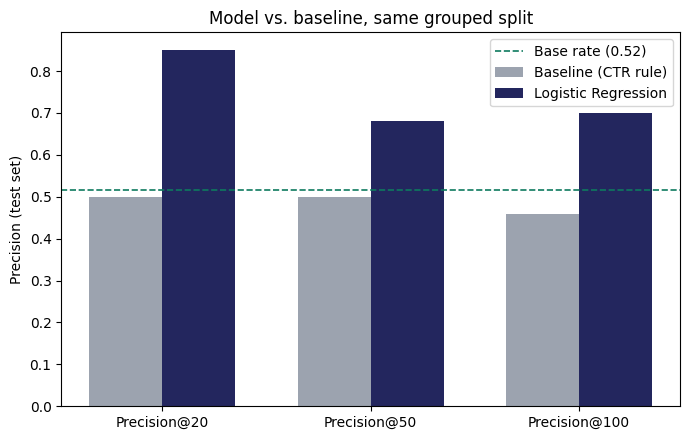

In [29]:
# Figure 1: model vs baseline, precision@K
fig, ax = plt.subplots(figsize=(7,4.5))
ks = ['p@20','p@50','p@100']
x = np.arange(len(ks)); width = 0.35
ax.bar(x - width/2, results.iloc[0][ks].values, width, label='Baseline (CTR rule)', color='#9CA3AF')
ax.bar(x + width/2, results.iloc[1][ks].values, width, label='Logistic Regression', color='#23265E')
ax.axhline(base_rate, color='#0E7A5F', linestyle='--', linewidth=1.2, label=f'Base rate ({base_rate:.2f})')
ax.set_xticks(x); ax.set_xticklabels(['Precision@20','Precision@50','Precision@100'])
ax.set_ylabel('Precision (test set)')
ax.set_title('Model vs. baseline, same grouped split')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/model_vs_baseline_precision.png', dpi=150)
plt.show()


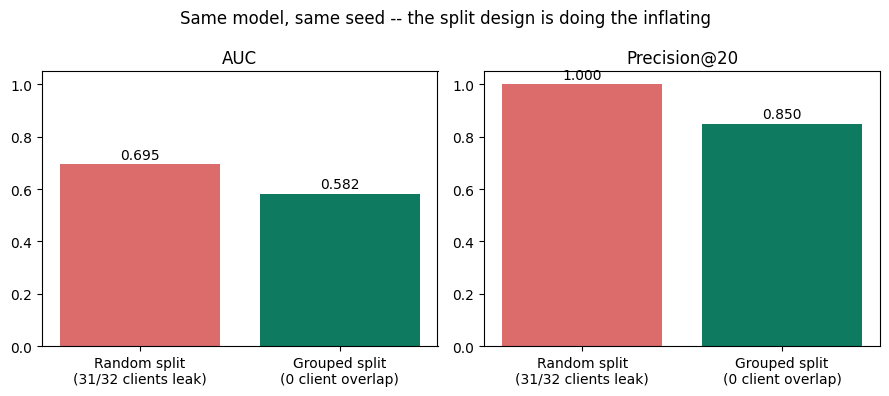

In [30]:
# Figure 2: honest vs naive split -- the leakage-inflation gap
train_r, test_r = train_test_split(df, test_size=0.25, random_state=RANDOM_SEED, stratify=df[TARGET])
train_r, test_r, flags_r = add_missing_flags(train_r, test_r, SYSTEMATIC_MISSING)
num_final_r = numeric_cols + flags_r
pipe_r = Pipeline([('prep', ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num_final_r),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='constant', fill_value='missing')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
])), ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_SEED))])
pipe_r.fit(train_r[num_final_r + categorical_cols], train_r[TARGET])
test_r = test_r.copy()
test_r['score'] = pipe_r.predict_proba(test_r[num_final_r + categorical_cols])[:, 1]
auc_random = roc_auc_score(test_r[TARGET], test_r['score'])
p20_random = precision_at_k(test_r, 'score', 20)
auc_grouped = roc_auc_score(test_g[TARGET], test_g['model_score'])
p20_grouped = precision_at_k(test_g, 'model_score', 20)

fig, axes = plt.subplots(1, 2, figsize=(9,4))
for ax, (label, rand_v, grp_v) in zip(axes, [('AUC', auc_random, auc_grouped), ('Precision@20', p20_random, p20_grouped)]):
    ax.bar(['Random split\n(31/32 clients leak)', 'Grouped split\n(0 client overlap)'], [rand_v, grp_v], color=['#DC6B6B','#0E7A5F'])
    ax.set_title(label); ax.set_ylim(0,1.05)
    for i,v in enumerate([rand_v, grp_v]): ax.text(i, v+0.02, f'{v:.3f}', ha='center')
plt.suptitle('Same model, same seed -- the split design is doing the inflating')
plt.tight_layout()
plt.savefig('../figures/random_vs_grouped_split.png', dpi=150)
plt.show()


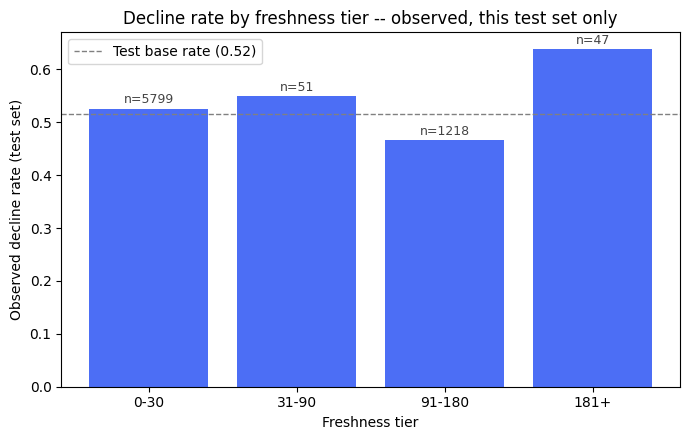

In [31]:
# Figure 3: decay/refresh insight
decay_insight = test_g.groupby('freshness_tier')[TARGET].agg(['mean','count']).reindex(['0-30','31-90','91-180','181+'])
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(decay_insight.index, decay_insight['mean'], color='#4C6EF5')
ax.axhline(base_rate, color='gray', linestyle='--', linewidth=1, label=f'Test base rate ({base_rate:.2f})')
for i,(rate,n) in enumerate(zip(decay_insight['mean'], decay_insight['count'])):
    ax.text(i, rate+0.01, f'n={n}', ha='center', fontsize=9, color='#444')
ax.set_ylabel('Observed decline rate (test set)'); ax.set_xlabel('Freshness tier')
ax.set_title('Decline rate by freshness tier -- observed, this test set only')
ax.legend(); plt.tight_layout()
plt.savefig('../figures/decline_rate_by_freshness_tier.png', dpi=150)
plt.show()


In [32]:
metrics = {
    'model': 'LogisticRegression, grouped split by client_id',
    'random_seed': RANDOM_SEED,
    'n_train_rows': len(train_g), 'n_test_rows': len(test_g),
    'n_train_clients': int(train_g['client_id'].nunique()), 'n_test_clients': int(test_g['client_id'].nunique()),
    'test_base_rate': round(float(base_rate),4),
    'model_auc': round(float(auc_grouped),4), 'baseline_auc': round(float(roc_auc_score(test_g[TARGET], test_g['baseline_score'])),4),
    'model_precision_at_20': round(float(p20_grouped),4),
    'random_split_auc': round(float(auc_random),4), 'random_split_precision_at_20': round(float(p20_random),4),
    'leakage_injection_auc': 0.723, 'leakage_injection_delta': 0.141,
    'decay_insight_by_freshness_tier': {k: round(float(v),4) for k,v in decay_insight['mean'].to_dict().items()},
    'top100_archetype_counts': queue.head(100)['archetype'].value_counts().to_dict(),
}
with open('../figures/capstone_metrics.json','w') as f:
    json.dump(metrics, f, indent=2)
print('Saved ../figures/capstone_metrics.json -- the paper cites these numbers directly.')
metrics


Saved ../figures/capstone_metrics.json -- the paper cites these numbers directly.


{'model': 'LogisticRegression, grouped split by client_id',
 'random_seed': 42,
 'n_train_rows': 22885,
 'n_test_rows': 7115,
 'n_train_clients': 24,
 'n_test_clients': 8,
 'test_base_rate': 0.5165,
 'model_auc': 0.5824,
 'baseline_auc': 0.5078,
 'model_precision_at_20': 0.85,
 'random_split_auc': 0.6955,
 'random_split_precision_at_20': 1.0,
 'leakage_injection_auc': 0.723,
 'leakage_injection_delta': 0.141,
 'decay_insight_by_freshness_tier': {'0-30': 0.5258,
  '31-90': 0.549,
  '91-180': 0.4663,
  '181+': 0.6383},
 'top100_archetype_counts': {'refreshed_but_still_declining': 71,
  'stale_and_declining': 16,
  'high_value_declining': 8,
  'moderate_signal': 5}}

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.